<a href="https://colab.research.google.com/github/chamcihn/MoblieSoftwareProject/blob/master/3_%EB%8B%A8%EA%B3%84%EB%B3%84_%EB%AA%A8%EB%8D%B8%EB%A7%81.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**스마트폰 센서 데이터 기반 모션 분류**
# 단계3 : 단계별 모델링


## 0.미션4

* 단계별로 나눠서 모델링을 수행하고자 합니다.  
* 단계 구분 예시
    * 단계1 : 정적(0), 동적(1) 행동 분류 모델 생성
    * 단계2 : 세부 동작에 대한 분류모델 생성
        * 단계1 모델에서 0으로 예측 -> 정적 행동 3가지 분류 모델링
        * 단계1 모델에서 1으로 예측 -> 동적 행동 3가지 분류 모델링
* (선택) 모델 통합
    * 두 단계 모델을 통합하고, 새로운 데이터에 대해서 최종 예측결과와 성능평가가 나오도록 함수로 만들기
* 성능 비교
    * 기본 모델링의 성능과 비교
    * 성능 가이드
        * Accuracy : 0.97 ~ 0.99
* (선택) 파이프라인 구성
    * test 데이터를 입력하여, 전처리 및 예측결과가 나오도록 함수 구성

## 1.환경설정

* 세부 요구사항
    - 경로 설정 : 구글콜랩
        * 구글 드라이브 바로 밑에 project3 폴더를 만들고,
        * 데이터 파일을 복사해 넣습니다.
    - 기본적으로 필요한 라이브러리를 import 하도록 코드가 작성되어 있습니다.
        * 필요하다고 판단되는 라이브러리를 추가하세요.


### (1) 경로 설정

* 구글 드라이브 연결

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
path = '/content/drive/MyDrive/aivle/'

### (2) 라이브러리 불러오기

* 라이브러리 로딩
  - pandas, numpy,matplotlib,seaborn, joblib, 모델링에 필요한 라이브러리를 로딩합니다.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import *

from keras.models import Sequential
from keras.layers import Dense, Flatten, Dropout, Input
from keras.backend import clear_session
from keras.optimizers import Adam

In [4]:
# 학습곡선 함수
def dl_history_plot(history):
    plt.figure(figsize=(10,6))
    plt.plot(history['loss'], label='train_err', marker = '.')
    plt.plot(history['val_loss'], label='val_err', marker = '.')

    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.grid()
    plt.show()

### (3) 데이터 불러오기

* 주어진 데이터셋
    * data01_train.csv : 학습 및 검증용
    * data01_test.csv : 테스트용
    * feature.csv : feature 이름을 계층구조로 정리한 데이터

* 세부 요구사항
    * 칼럼 삭제 : data01_train.csv와 data01_test.csv 에서 'subject' 칼럼은 불필요하므로 삭제합니다.

#### 1) 데이터로딩

In [5]:
# 주어진 데이터 셋을 불러오세요.(3개)
df_train = pd.read_csv('/content/drive/MyDrive/aivle/data01_train.csv')
df_test = pd.read_csv('/content/drive/MyDrive/aivle/data01_test.csv')
df_feature = pd.read_csv('/content/drive/MyDrive/aivle/features.csv')

In [6]:
#불필요한 칼럼을 삭제하세요.

In [7]:
df_train.drop('subject',axis=1,inplace=True)
df_test.drop('subject',axis=1,inplace=True)

#### 2) 기본 정보 조회

In [8]:
#전체 데이터의 행,열 개수 확인
df_train.shape

(5881, 562)

In [9]:
#전체 데이터의 상위 5개 행 확인
df_feature.head()

,sensor,agg,axis,feature_name
0,tBodyAcc,mean(),X,tBodyAcc-mean()-X
1,tBodyAcc,mean(),Y,tBodyAcc-mean()-Y
2,tBodyAcc,mean(),Z,tBodyAcc-mean()-Z
3,tBodyAcc,std(),X,tBodyAcc-std()-X
4,tBodyAcc,std(),Y,tBodyAcc-std()-Y


In [10]:
#전체 데이터의 수치형 변수 분포 확인
df_train.describe()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-meanFreq(),fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)"
count,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,...,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000
mean,0.274811,-0.017799,-0.109396,-0.603138,-0.509815,-0.604058,-0.628151,-0.525944,-0.605374,-0.465490,...,0.126955,-0.305883,-0.623548,0.008524,-0.001185,0.009340,-0.007099,-0.491501,0.059299,-0.054594
std,0.067614,0.039422,0.058373,0.448807,0.501815,0.417319,0.424345,0.485115,0.413043,0.544995,...,0.249176,0.322808,0.310371,0.339730,0.447197,0.608190,0.476738,0.509069,0.297340,0.278479
min,-0.503823,-0.684893,-1.000000,-1.000000,-0.999844,-0.999667,-1.000000,-0.999419,-1.000000,-1.000000,...,-0.965725,-0.979261,-0.999765,-0.976580,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-0.980143
25%,0.262919,-0.024877,-0.121051,-0.992774,-0.977680,-0.980127,-0.993602,-0.977865,-0.980112,-0.936067,...,-0.021610,-0.541969,-0.845985,-0.122361,-0.294369,-0.481718,-0.373345,-0.811397,-0.018203,-0.141555
50%,0.277154,-0.017221,-0.108781,-0.943933,-0.844575,-0.856352,-0.948501,-0.849266,-0.849896,-0.878729,...,0.133887,-0.342923,-0.712677,0.010278,0.005146,0.011448,-0.000847,-0.709441,0.182893,0.003951
75%,0.288526,-0.010920,-0.098163,-0.242130,-0.034499,-0.262690,-0.291138,-0.068857,-0.268539,-0.013690,...,0.288944,-0.127371,-0.501158,0.154985,0.285030,0.499857,0.356236,-0.511330,0.248435,0.111932
max,1.000000,1.000000,1.000000,1.000000,0.916238,1.000000,1.000000,0.967664,1.000000,1.000000,...,0.946700,0.989538,0.956845,1.000000,1.000000,0.998702,0.996078,0.977344,0.478157,1.000000


In [11]:
#전체 데이터의 모든 변수 확인
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5881 entries, 0 to 5880
Columns: 562 entries, tBodyAcc-mean()-X to Activity
dtypes: float64(561), object(1)
memory usage: 25.2+ MB


## 2.데이터 전처리

* 세부 요구사항
    - Label 추가 : 1단계 모델을 위한 레이블 추가
    - train : val = 8 : 2 혹은 7 : 3
    - random_state 옵션을 사용하여 다른 모델과 비교를 위해 성능이 재현되도록 합니다.

### (1) 1단계 모델링을 위한 레이블

In [51]:
#Lable 추가(1단계 모델:정적(0), 동적(1) 행동 분류 모델 생성 )
#is dynamic 변수를 추가하세요(값 0, 값 1 확인해서!)
static_actions = ['STANDING', 'SITTING', 'LAYING']

df_train['is_dynamic'] = df_train['Activity'].apply(lambda x: 0 if x in static_actions else 1)

# 값 확인
print(df_train['is_dynamic'].value_counts())

is_dynamic
0    3234
1    2647
Name: count, dtype: int64


### (2) x, y 분리

In [52]:
#x,y 분리하기
x = df_train.drop(columns=['Activity','is_dynamic'])
y = df_train['is_dynamic']
x_train, x_val, y_train, y_val = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

### (3) 스케일링


* 세부 요구사항
    - 스케일링을 필요로 하는 알고리즘 사용을 위해서 코드 수행
    - min-max 방식 혹은 standard 방식 중 한가지 사용.

In [53]:
#스케일링 방식을 선택해서 스케일링을 진행합니다.
scaler = MinMaxScaler()
x_train = scaler.fit_transform(x_train)
x_val = scaler.transform(x_val)

### (4) 데이터 분할
* train, val 분할

## **3.단계별 모델링**

### (1) 단계1

* 세부 요구사항
    * 적절한 단계로 구분한 후, 1단계를 분류하는 모델 생성
        * 예시 : 정적 행동(Laying, Sitting, Standing)과 동적 행동(동적 : Walking, Walking-Up, Walking-Down)을 구분하는 모델 생성.
    * 몇 가지 모델을 만들고 가장 성능이 좋은 모델을 선정하시오.(기본 모델링 참고)

#### 1) 모델1

In [54]:
# 모델 설계
model_dy = Sequential([
    Input(shape=(x_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')  # 이진 분류이므로 sigmoid 사용
])

In [55]:
# 컴파일 및 학습
loss_fn = 'binary_crossentropy'
optimizer = Adam(learning_rate= 0.002)
model_dy.compile(optimizer=optimizer, loss=loss_fn, metrics=['accuracy'])

epochs = 5
tr_loss_list = []
val_loss_list = []


for t in range(epochs):
    hist = model_dy.fit(x_train, y_train, validation_data=(x_val, y_val), batch_size=64, epochs=1, verbose=0)
    tr_loss = hist.history['loss'][0]
    val_loss = hist.history['val_loss'][0]

    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)


    print(f"Epoch {t+1}, train loss : {tr_loss:.4f}, val loss : {val_loss:.4f}")

Epoch 1, train loss : 0.0301, val loss : 0.0097
Epoch 2, train loss : 0.0030, val loss : 0.0074
Epoch 3, train loss : 0.0027, val loss : 0.0139
Epoch 4, train loss : 0.0018, val loss : 0.0018
Epoch 5, train loss : 0.0003, val loss : 0.0022


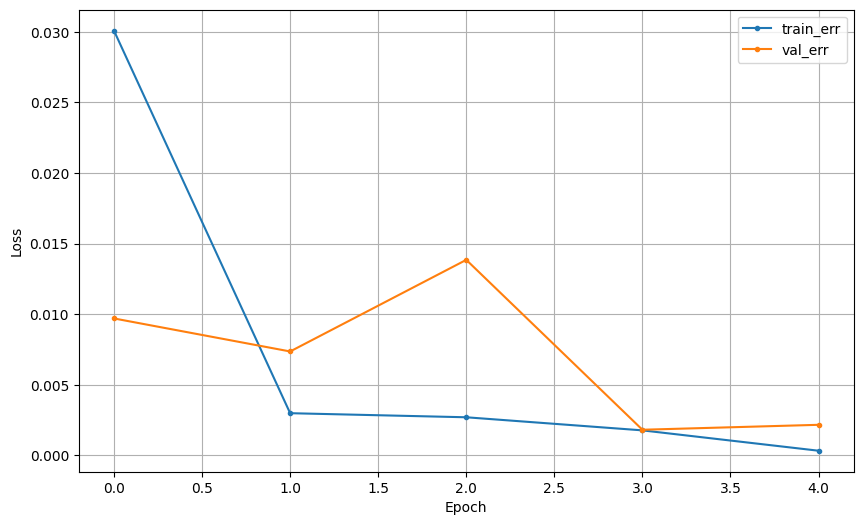

In [56]:
# 학습곡선
dl_history_plot({
    'loss': tr_loss_list,
    'val_loss': val_loss_list
})


In [57]:
# 예측 및 평가
pred = model_dy.predict(x_val)
pred_label = np.argmax(pred, axis=1)

acc = accuracy_score(y_val, pred_label)
print(f"최종 정확도: {acc:.4f}")

37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
최종 정확도: 0.5497


#### 2) 모델2

In [58]:
# 모델 설계
model_dy2 = Sequential([
    Input(shape=(x_train.shape[1],)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

In [59]:
# 컴파일 및 학습
loss_fn = 'binary_crossentropy'
optimizer = Adam(learning_rate= 0.002)
model_dy2.compile(optimizer=optimizer, loss=loss_fn, metrics=['accuracy'])

epochs = 5
tr_loss_list = []
val_loss_list = []


for t in range(epochs):
    hist2 = model_dy2.fit(x_train, y_train, validation_data=(x_val, y_val), batch_size=64, epochs=1, verbose=0)
    tr_loss = hist2.history['loss'][0]
    val_loss = hist2.history['val_loss'][0]

    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)


    print(f"Epoch {t+1}, train loss : {tr_loss:.4f}, val loss : {val_loss:.4f}")

Epoch 1, train loss : 0.0340, val loss : 0.0101
Epoch 2, train loss : 0.0038, val loss : 0.0023
Epoch 3, train loss : 0.0019, val loss : 0.0007
Epoch 4, train loss : 0.0003, val loss : 0.0006
Epoch 5, train loss : 0.0019, val loss : 0.0001


In [60]:
print(np.unique(y_train))  # [0 1] 이어야 함


[0 1]


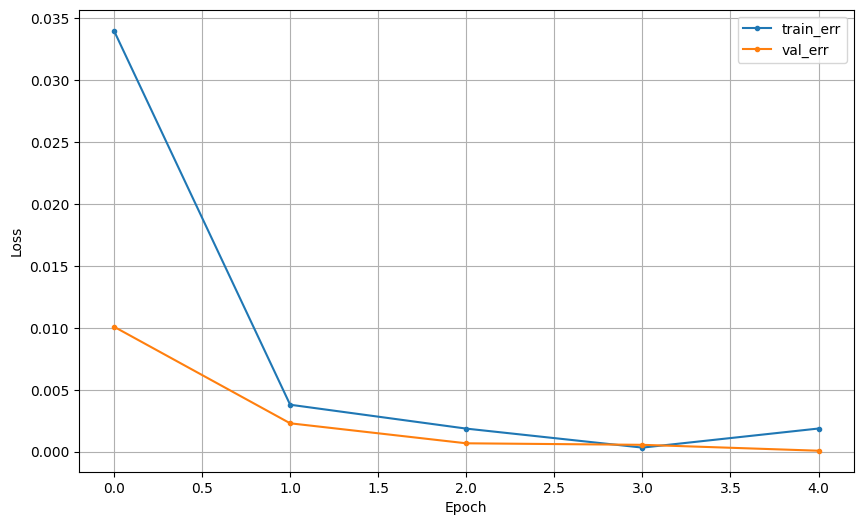

In [61]:
# 학습곡선
dl_history_plot({
    'loss': tr_loss_list,
    'val_loss': val_loss_list
})


In [62]:
# 예측 및 평가
pred = model_dy2.predict(x_val)
pred_label = np.argmax(pred, axis=1)

acc = accuracy_score(y_val, pred_label)
print(f"최종 정확도: {acc:.4f}")

37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
최종 정확도: 0.5497


### (2) 단계2

#### 1) 단계2-1 : 정적 동작 세부 분류

* 세부 요구사항
    * 정적 행동(Laying, Sitting, Standing)인 데이터 추출
    * Laying, Sitting, Standing 를 분류하는 모델을 생성
    * 몇가지 모델을 만들고 가장 성능이 좋은 모델을 선정하시오.

In [63]:
# (tip) 정적 행동(0)인 데이터 추출
static_actions = ['LAYING', 'SITTING', 'STANDING']
df_static = df_train[df_train['Activity'].isin(static_actions)].copy()


In [64]:
# (tip) 인코딩 진행, map 활용해서 숫자레이블로 매핑핑
label_map = {'LAYING': 0, 'SITTING': 1, 'STANDING': 2}
df_static['Activity'] = df_static['Activity'].map(label_map)


In [65]:
# 모델 설계
x = df_static.drop(columns=['Activity',  'is_dynamic'])
y = df_static['Activity']
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.2, stratify=y, random_state=42)

scaler = MinMaxScaler()
x_train = scaler.fit_transform(x_train)
x_val = scaler.transform(x_val)

In [66]:
# 컴파일 및 학습
clear_session()
model2_1 = Sequential([
    Input(shape=(x_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(3, activation='softmax')  # 클래스 수가 3개이므로 softmax
])

model2_1.compile(optimizer=Adam(learning_rate=0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history2_1 = model2_1.fit(x_train, y_train,
                    validation_data=(x_val, y_val),
                    epochs=10, batch_size=64)


Epoch 1/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6611 - loss: 0.9087 - val_accuracy: 0.8207 - val_loss: 0.5823
Epoch 2/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8638 - loss: 0.5093 - val_accuracy: 0.8640 - val_loss: 0.4146
Epoch 3/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8945 - loss: 0.3624 - val_accuracy: 0.8810 - val_loss: 0.3307
Epoch 4/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9104 - loss: 0.2877 - val_accuracy: 0.8918 - val_loss: 0.2950
Epoch 5/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9143 - loss: 0.2516 - val_accuracy: 0.9073 - val_loss: 0.2504
Epoch 6/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9324 - loss: 0.2025 - val_accuracy: 0.9119 - val_loss: 0.2276
Epoch 7/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9254 - loss: 0.1963 - val_accuracy: 0.9243 - val_loss: 0.2112
Epoch 8/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9414 - loss: 0.1762 - val_accuracy: 0.9289 - val_loss

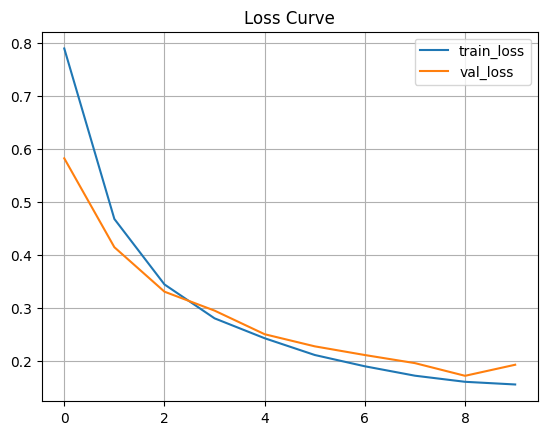

In [67]:
# 학습곡선
plt.plot(history2_1.history['loss'], label='train_loss')
plt.plot(history2_1.history['val_loss'], label='val_loss')
plt.legend()
plt.grid()
plt.title("Loss Curve")
plt.show()


In [68]:
# 예측 및 평가
pred = model2_1.predict(x_val)
pred_label = np.argmax(pred, axis=1)

acc = accuracy_score(y_val, pred_label)
print(f"최종 정확도: {acc:.4f}")

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
최종 정확도: 0.9243


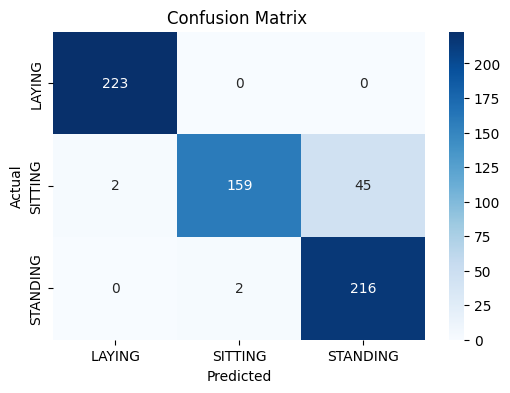

In [69]:
cm = confusion_matrix(y_val, pred_label)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['LAYING', 'SITTING', 'STANDING'],
            yticklabels=['LAYING', 'SITTING', 'STANDING'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix ')
plt.show()

#### 2) 단계2-2 : 동적 동작 세부 분류

* 세부 요구사항
    * 동적 행동(Walking, Walking Upstairs, Walking Downstairs)인 데이터 추출
    * Walking, Walking Upstairs, Walking Downstairs 를 분류하는 모델을 생성
    * 몇가지 모델을 만들고 가장 성능이 좋은 모델을 선정하시오.

In [30]:
# (tip) 동적 행동(1)인 데이터 추출

In [31]:
# (tip) map 활용해서 숫자레이블로 매핑핑

In [32]:
# 모델 설계

In [33]:
# 컴파일 및 학습

In [34]:
# 학습곡선

In [35]:
# 예측 및 평가

### (3) (옵션) 분류 모델 파이프라인 구성


* 세부 요구사항
    * 두 단계 모델을 통합하고, 새로운 데이터(test)에 대해서 최종 예측결과와 성능평가가 나오도록 함수로 만들기
    * 데이터 파이프라인 구축 : test데이터가 로딩되어 전처리 과정을 거치고, 예측 및 성능 평가 수행

* 예시
![](https://github.com/DA4BAM/image/blob/main/pipeline%20function.png?raw=true)

#### 1) 함수 만들기

In [36]:
#(tip) 함수 만들기
# 1. 전처리
# 1-1. 스케일링
# 1-2. 입력값 만들기
#-------------------
# 2. 예측하기
# 2-1. 단계1을 모델로 0,1 구분
# 2-2. 단계 1의 결과로 데이터 나누기
# 2-3. 단계2 모델로 예측
# 2-4. 예측 결과 원래 값으로 변환
# 2-5. 하나로 합쳐보기
#-------------------
# 3. 최종 성능평가 하기

In [37]:
# (옵션) 위 참고해서 분류모델 파이프라인 만들어보기

#### 2) test 셋으로 예측하고 평가하기

In [38]:
# test 셋의 구조 한번 확인해보고 성능평가 해보기